In [1]:
%pip install skorch
%pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.3 MB/s eta 0:00:00


In [2]:
# Imports
import pathlib, json, torch, sklearn, skopt, skorch, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Read x data
x_train = np.load("x_train.npy")
x_val = np.load("x_val.npy")
x_test = np.load("x_test.npy")

# Read y data
y_train = pd.read_csv("y_train.csv")
y_val = pd.read_csv("y_val.csv")
y_test = pd.read_csv("y_test.csv")

In [4]:
# Convert labels to numbers
mapping = {"True": 1, "Fake": 0}

# Convert to array
y_train = y_train["outcome"].map(mapping).to_numpy(dtype = np.float32)
y_val = y_val["outcome"].map(mapping).to_numpy(dtype = np.float32)
y_test = y_test["outcome"].map(mapping).to_numpy(dtype = np.float32)

In [5]:
# Create our MLP architecture
class MLPClassifier(torch.nn.Module):
  def __init__(self, input_dim, hidden_dim, dropout_rate, num_hidden_layers):
    super().__init__()

    # Where we store our layers
    layers = []

    # First set of layers
    layers.append(torch.nn.Linear(input_dim, hidden_dim))
    layers.append(torch.nn.GELU())
    layers.append(torch.nn.Dropout(dropout_rate))

    # Extra layers
    for i in range(num_hidden_layers - 1):
      next_dim = max(hidden_dim // 2, 2)
      layers.append(torch.nn.Linear(hidden_dim, next_dim))
      layers.append(torch.nn.GELU())
      layers.append(torch.nn.Dropout(dropout_rate))
      hidden_dim = next_dim

    # Final layer
    layers.append(torch.nn.Linear(hidden_dim, 1))

    # Add to our network
    self.network = torch.nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)

In [6]:
# Establish our early stopping for the MLP
early_stopping = skorch.callbacks.EarlyStopping(monitor = "valid_loss",
                                                patience = 3,
                                                threshold = 1e-3,
                                                lower_is_better = True,
                                                load_best = True)

# Convert our MLP to sklearn
mlp = skorch.NeuralNetBinaryClassifier(module = MLPClassifier,
                                       criterion = torch.nn.BCEWithLogitsLoss,
                                       optimizer = torch.optim.AdamW,
                                       max_epochs = 1000,
                                       callbacks = [early_stopping],
                                       iterator_train__shuffle = True,
                                       device = "cuda" if torch.cuda.is_available() else "cpu",
                                       verbose = 0)

In [7]:
# What models do we want to try?
experiments = {"Logistic Regression":    {"model":  sklearn.linear_model.LogisticRegression(tol = 1e-3,
                                                                                            fit_intercept = True,
                                                                                            solver = "liblinear",
                                                                                            max_iter = 1000,
                                                                                            verbose = 0),
                                          "params": {"C":       skopt.space.Real(1e-4, 1e+4, prior = "log-uniform"),
                                                     "penalty": skopt.space.Categorical(["l2", "l1"])}},

               "Random Forest":          {"model":  sklearn.ensemble.RandomForestClassifier(verbose = 0),
                                          "params": {"n_estimators":      skopt.space.Integer(50, 250),
                                                     "max_depth":         skopt.space.Integer(5, 30),
                                                     "min_samples_split": skopt.space.Integer(2, 10),
                                                     "min_samples_leaf":  skopt.space.Integer(1, 5)}},

               "Support Vector Machine": {"model":  sklearn.svm.SVC(tol = 1e-3,
                                                                    kernel = "rbf",
                                                                    max_iter = 1000,
                                                                    probability = True,
                                                                    verbose = False),
                                          "params": {"C":     skopt.space.Real(1e-3, 1e+3, prior = "log-uniform"),
                                                     "gamma": skopt.space.Categorical(["scale", "auto"])}},

               "Multilayer Perceptron":  {"model":  mlp,
                                          "params": {"module__input_dim":           skopt.space.Categorical([x_train.shape[1]]),
                                                     "module__hidden_dim":          skopt.space.Categorical([128, 256, 512]),
                                                     "module__dropout_rate":        skopt.space.Real(0.4, 0.8),
                                                     "module__num_hidden_layers":   skopt.space.Integer(1, 4),
                                                     "optimizer__weight_decay":     skopt.space.Real(1e-5, 1e-1, prior = "log-uniform"),
                                                     "lr":                          skopt.space.Real(1e-5, 1e-1, prior = "log-uniform"),
                                                     "batch_size":                  skopt.space.Categorical([32, 64, 128])}}}

In [8]:
# Combine training and validation data
x_search = np.vstack((x_train, x_val))
y_search = np.concatenate((y_train, y_val))

# Ensure the model still splits the training and testing data the way that we want
custom_split = sklearn.model_selection.PredefinedSplit(test_fold = np.concatenate((np.full(len(x_train), -1), np.full(len(x_val), 0))))

In [9]:
# Save our results
best_models = {}

# Loop through our options
for name, config in experiments.items():
  # Load model if we already did this one
  if pathlib.Path(f"{name.replace(" ", "_")}.joblib").exists():
    print(f"\nFound previous {name} model.")

    with open(f"{name.replace(" ", "_")}.json", "r") as fp:
      best_params = json.load(fp)
    best_estimator = joblib.load(f"{name.replace(" ", "_")}.joblib")

    best_models[name] = (best_estimator, best_params)

    continue

  print(f"\nOptimizing: {name}.")

  # Setup the Bayesian search
  search = skopt.BayesSearchCV(estimator = config["model"],
                                search_spaces = config["params"],
                                scoring = "accuracy",
                                n_iter = 16,
                                n_jobs = 1 if name == "Multilayer Perceptron" else -1,
                                n_points = 2,
                                cv = custom_split,
                                verbose = 1)

  # Execute the search
  search.fit(x_search, y_search)

  # Save the best model
  best_models[name] = (search.best_estimator_, search.best_params_)
  with open(f"{name.replace(" ", "_")}.json", "w") as fp:
    json.dump(search.best_params_, fp)
  joblib.dump(search.best_estimator_, f"{name.replace(" ", "_")}.joblib")


Found previous Logistic Regression model.

Found previous Random Forest model.

Found previous Support Vector Machine model.

Optimizing: Multilayer Perceptron.
Fitting 1 folds for each of 2 candidates, totalling 2 fits
Fitting 1 folds for each of 2 candidates, totalling 2 fits
Fitting 1 folds for each of 2 candidates, totalling 2 fits
Fitting 1 folds for each of 2 candidates, totalling 2 fits
Fitting 1 folds for each of 2 candidates, totalling 2 fits
Fitting 1 folds for each of 2 candidates, totalling 2 fits
Fitting 1 folds for each of 2 candidates, totalling 2 fits
Fitting 1 folds for each of 2 candidates, totalling 2 fits


In [10]:
# Save the outputs
metrics = {}

# Loop through the saved models
for name, (model, params) in best_models.items():
  print(f"\nEvaluating: {name}.")

  # Calculate and save accuracies
  accuracies = {}
  accuracies["train"] = sklearn.metrics.accuracy_score(y_train, model.predict(x_train))
  accuracies["val"] = sklearn.metrics.accuracy_score(y_val, model.predict(x_val))
  accuracies["test"] = sklearn.metrics.accuracy_score(y_test, model.predict(x_test))

  # Save accuracies
  metrics[name] = accuracies

  # Print accuracies
  print(f"Train: {accuracies["train"]:.4f}")
  print(f"Val:   {accuracies["val"]:.4f}")
  print(f"Test:  {accuracies["test"]:.4f}")

  # Print confusion matrix
  print(sklearn.metrics.confusion_matrix(y_test, model.predict(x_test)))


Evaluating: Logistic Regression.
Train: 1.0000
Val:   1.0000
Test:  0.9997
[[1744    1]
 [   0 2120]]

Evaluating: Random Forest.
Train: 0.9996
Val:   1.0000
Test:  0.9845
[[1704   41]
 [  19 2101]]

Evaluating: Support Vector Machine.
Train: 0.9994
Val:   1.0000
Test:  0.9995
[[1743    2]
 [   0 2120]]

Evaluating: Multilayer Perceptron.
Train: 0.9992
Val:   0.9997
Test:  0.9987
[[1741    4]
 [   1 2119]]


Text(0.5, 1.0, 'Model Testing Accuracies')

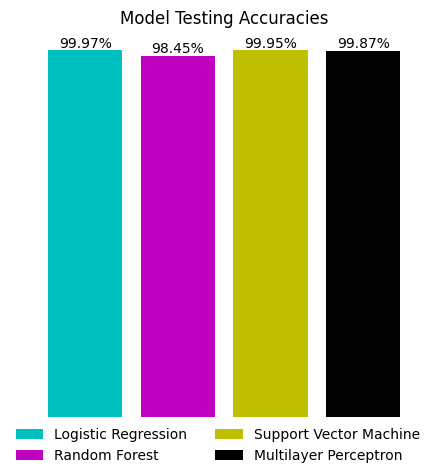

In [11]:
# Plot the final model testing accuracies

# Initialize figure
fig, ax = plt.subplots(1, 1, figsize = (5, 5))

# Add the data
bars = ax.bar(metrics.keys(),
              [metrics[model]["test"] for model in metrics.keys()],
              color = ["c", "m", "y", "k"])

# Create a legend
fig.legend(bars, metrics.keys(), loc = "lower center", ncol = 2, frameon = False)

# Remove the spines
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Remove the ticks and labels
ax.set_xticks([])
ax.set_yticks([])

# Add labels to the bars
labels = [f"{bar.get_height() * 100:.2f}%" for bar in bars]
ax.bar_label(bars, labels = labels)

# Set titles
ax.set_title("Model Testing Accuracies")